In [ ]:
!pip install -q tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import libraries
import numpy as np
import os
from PIL import Image

# Step 3: Load your ulcer masks from .npy file
npy_path = "/content/drive/MyDrive/corneal_ulcer_dataset/train_ulcer.npy"
ulcer_masks = np.load(npy_path)
print("Loaded .npy masks shape:", ulcer_masks.shape)

# Step 4: Save masks as PNGs in Colab temporary folder
output_dir = "/content/ulcer_masks_png"
os.makedirs(output_dir, exist_ok=True)

for i, mask in enumerate(ulcer_masks):
    img = (mask * 255).astype(np.uint8)  # Convert from [0,1] to [0,255]
    Image.fromarray(img.squeeze()).save(f"{output_dir}/mask_{i}.png")

print(f"Saved {len(ulcer_masks)} masks to {output_dir}")

# Step 5: Load PNGs and normalize
def load_images(path, img_size=(64,64)):
    images = []
    for fname in sorted(os.listdir(path)):
        img = Image.open(os.path.join(path, fname)).convert('L')  # grayscale
        img = img.resize(img_size)
        img = np.array(img)/255.0  # normalize to [0,1]
        images.append(img)
    images = np.expand_dims(images, axis=-1)  # shape: (N, H, W, 1)
    return np.array(images)

ulcer_images = load_images(output_dir)
print("Loaded images shape:", ulcer_images.shape)
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import libraries
import numpy as np
import os
from PIL import Image

# Step 3: Load your ulcer masks from .npy file
npy_path = "/content/drive/MyDrive/corneal_ulcer_dataset/train_ulcer.npy"
ulcer_masks = np.load(npy_path)
print("Loaded .npy masks shape:", ulcer_masks.shape)

# Step 4: Save masks as PNGs in Colab temporary folder
output_dir = "/content/ulcer_masks_png"
os.makedirs(output_dir, exist_ok=True)

for i, mask in enumerate(ulcer_masks):
    img = (mask * 255).astype(np.uint8)  # Convert from [0,1] to [0,255]
    Image.fromarray(img.squeeze()).save(f"{output_dir}/mask_{i}.png")

print(f"Saved {len(ulcer_masks)} masks to {output_dir}")

# Step 5: Load PNGs and normalize
def load_images(path, img_size=(64,64)):
    images = []
    for fname in sorted(os.listdir(path)):
        img = Image.open(os.path.join(path, fname)).convert('L')  # grayscale
        img = img.resize(img_size)
        img = np.array(img)/255.0  # normalize to [0,1]
        images.append(img)
    images = np.expand_dims(images, axis=-1)  # shape: (N, H, W, 1)
    return np.array(images)

ulcer_images = load_images(output_dir)
print("Loaded images shape:", ulcer_images.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded .npy masks shape: (247, 256, 256)
Saved 247 masks to /content/ulcer_masks_png
Loaded images shape: (247, 64, 64, 1)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded .npy masks shape: (247, 256, 256)
Saved 247 masks to /content/ulcer_masks_png
Loaded images shape: (247, 64, 64, 1)


In [ ]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(8*8*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8, 8, 256)))

    model.add(layers.Conv2DTranspose(128, (5,5), strides=(2,2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding='same', use_bias=False, activation='tanh'))
    return model

generator = make_generator_model()
generator.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16384)          │     1,638,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,730,304 (10.42 MB)

 Trainable params: 2,697,152 (10.29 MB)

 Non-trainable params: 33,152 (129.50 KB)

In [ ]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5,5), strides=(2,2), padding='same', input_shape=[64,64,1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5,5), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

discriminator = make_discriminator_model()
discriminator.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        32,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239,361 (935.00 KB)

 Trainable params: 239,361 (935.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)


In [ ]:
EPOCHS = 50
BATCH_SIZE = 8
noise_dim = 100
#i am gonna change it later to inclide more to 4000 masks
num_examples_to_generate = 500

# Prepare dataset
train_dataset = tf.data.Dataset.from_tensor_slices(ulcer_images).shuffle(100).batch(BATCH_SIZE)

# Seed for consistent generated images
seed = tf.random.normal([num_examples_to_generate, noise_dim])

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)

        print(f'Epoch {epoch+1} completed')
        # Optional: generate sample images
        generate_and_save_images(generator, epoch+1, seed)

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(10,2))
    for i in range(predictions.shape[0]):
        plt.subplot(1, predictions.shape[0], i+1)
        plt.imshow(predictions[i,:,:,0]*0.5+0.5, cmap='gray')
        plt.axis('off')
    plt.show()


In [ ]:
train(train_dataset, EPOCHS)


Epoch 1 completed


Epoch 2 completed


Epoch 3 completed


Epoch 4 completed


Epoch 5 completed


Epoch 6 completed


Epoch 7 completed


Epoch 8 completed


Epoch 9 completed


Epoch 10 completed


Epoch 11 completed


Epoch 12 completed


Epoch 13 completed


Epoch 14 completed


Epoch 15 completed


Epoch 16 completed


Epoch 17 completed


Epoch 18 completed


Epoch 19 completed


Epoch 20 completed


Epoch 21 completed


Epoch 22 completed


Epoch 23 completed


Epoch 24 completed


Epoch 25 completed


Epoch 26 completed


Epoch 27 completed


Epoch 28 completed


Epoch 29 completed


Epoch 30 completed


Epoch 31 completed


Epoch 32 completed


Epoch 33 completed


Epoch 34 completed


Epoch 35 completed


Epoch 36 completed


Epoch 37 completed


Epoch 38 completed


Epoch 39 completed


Epoch 40 completed


Epoch 41 completed


Epoch 42 completed


Epoch 43 completed


Epoch 44 completed


Epoch 45 completed


Epoch 46 completed


Epoch 47 completed


Epoch 48 completed


Epoch 49 completed


Epoch 50 completed


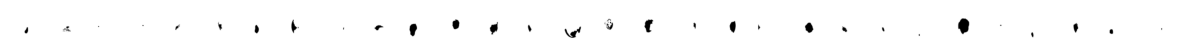

In [ ]:
import matplotlib.pyplot as plt

# Show 5 random masks
num_to_show = 30
plt.figure(figsize=(15,3))
for i in range(num_to_show):
    plt.subplot(1, num_to_show, i+1)
    plt.imshow(ulcer_images[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()


In [ ]:
parent_dir = "/content/drive/MyDrive/corneal_ulcer_dataset"

# New folder for generated masks
generated_dir = os.path.join(parent_dir, "generated_ulcer_masks")
os.makedirs(generated_dir, exist_ok=True)

def generate_and_save_masks_drive(model, num_images=500, noise_dim=100, save_dir=generated_dir):
    """
    Generate num_images masks from the generator and save them as PNGs to Google Drive.
    """
    noise = tf.random.normal([num_images, noise_dim])
    generated_images = model(noise, training=False)

    for i in range(num_images):
        # Convert from [-1,1] to [0,255]
        img = (generated_images[i,:,:,0] * 0.5 + 0.5) * 255
        img = img.numpy().astype(np.uint8)
        Image.fromarray(img).save(os.path.join(save_dir, f"mask_{i}.png"))

    print(f"Saved {num_images} generated masks to {save_dir}")

# Call the function after training
generate_and_save_masks_drive(generator, num_images=500)

Saved 500 generated masks to /content/drive/MyDrive/corneal_ulcer_dataset/generated_ulcer_masks
